In [1]:
using DifferentialEquations
using Plots
include("Chemkin.jl")

# Initial species concentrations 0. T 1. N2, 2. O2, 3. CH4, 4. H2O, 5. CO2

species_names = ["N2", "O2", "CH4", "H2O", "CO2"]

X0 = [300, 31.9, 8.59, 6.14, 0, 0] # K, mol/m^3

# Stoichiometry: 2 O2 + CH4 -> 2 H2O + CO2
S = [0, -2, -1, 2, 1]  # N2 does not participate in the reaction

# Molar masses and enthalpies
M = [28.0134, 31.999, 16.04246, 18.01528, 44.01]*1e-3  # kg/mol

species_dict = load_chemical_data("CHEMKIN-THERMDAT.txt")

Dict{String, Tuple{Float64, Vector{Float64}}} with 550 entries:
  "HSIC"          => (1500.0, [5.84954, 0.000762835, -9.97413e-8, -3.81159e-11,…
  "H2S"           => (1000.0, [2.88315, 0.00382783, -1.4234e-6, 2.498e-10, -1.6…
  "SIF3NHSIH3"    => (1000.0, [16.6994, 0.00778978, -8.11057e-7, -7.6502e-10, 1…
  "CLSI(CH3)2CH2" => (1500.0, [21.151, 0.00801827, -7.92425e-7, -3.29505e-10, 5…
  "GEF2"          => (1000.0, [4.76795, 0.00841094, -1.67642e-5, 1.56225e-8, -5…
  "CSICL3"        => (1500.0, [12.5054, 0.000533922, -2.58861e-7, 6.07531e-11, …
  "H2GAME"        => (600.0, [5.8316, 0.0122287, 3.03367e-7, -3.95694e-9, 1.225…
  "O2-"           => (1000.0, [3.88301, 0.000740787, -2.96178e-7, 5.7243e-11, -…
  "ASALME"        => (600.0, [7.12711, 0.00735786, 2.3008e-8, -2.2264e-9, 6.927…
  "CH2CLCHCL2"    => (1500.0, [16.1874, 0.00304768, -5.0115e-7, -1.5967e-11, 7.…
  "CHCLCCLOH"     => (1500.0, [14.1221, 0.00258376, -4.5769e-7, 5.21568e-12, 3.…
  "H2SI(CH3)CH2"  => (1500.0, [13.8883, 0.007

In [2]:
function Arrhenius(X)
    T = X[1]

    Y = X[2:end]
    n_CH4 = 1.0
    n_O2 = 0.5
    A = 1.1e10
    Ea = 2e4
    R = 8.314

    k = A * exp(-Ea / (R * T))  # rate constant
    r = k * max(Y[3], 0)^n_CH4 * max(Y[2], 0)^n_O2 #mol/s
    return r
end

Arrhenius (generic function with 1 method)

In [3]:
# Temperature rate of change due to reaction enthalpy
function dT(X, r)
    h0_vec = []
    cp_vec = []
    for i in 1:length(X)-1
        append!(h0_vec, h0(X[1], species_dict[species_names[i]]))
        append!(cp_vec, species_cp(X[1], species_dict[species_names[i]])*1000)
    end
    dH = sum(-r.*S.*h0_vec) # 1/s * kJ/mol
    c_p = sum(X[2:end].*cp_vec)/sum(X[2:end]) #kJ/molK
    dT = dH/c_p #kJ/mols * molK/kJ
    return dT[1]
end

dT (generic function with 1 method)

In [4]:
# Derivative function for the ODE system
function f!(dX, X, p, t)
    r = Arrhenius(X)
    dX[1] = dT(X,r)
    dX[2:end] .= r .* S  # Species concentrations change
end

# Define time span and solve the ODE problem
tend = 1e-6
tspan = (0.0, tend)

# Define and solve the ODE problem with tighter tolerances
problem = ODEProblem(f!, X0, tspan)
sol = solve(problem)

retcode: Success
Interpolation: specialized 4th order "free" interpolation, specialized 2nd order "free" stiffness-aware interpolation
t: 23-element Vector{Float64}:
 0.0
 1.3721082389409618e-11
 1.5093190628350578e-10
 1.5230401452244673e-9
 5.878427197734067e-9
 1.2972118364088576e-8
 2.153944631603362e-8
 3.33092935594547e-8
 4.349545322289936e-8
 5.099214744879109e-8
 5.478123287217295e-8
 5.628879549569645e-8
 5.7730797087096e-8
 5.8463463185785504e-8
 5.8723664123306374e-8
 5.886967163916028e-8
 5.903664998667045e-8
 5.9160903191289595e-8
 5.933413280571207e-8
 6.106642894993683e-8
 7.838939039218435e-8
 2.516190048146596e-7
 1.0e-6
u: 23-element Vector{Vector{Float64}}:
 [300.0, 31.9, 8.59, 6.14, 0.0, 0.0]
 [300.0239735956444, 31.9, 8.588210936383971, 6.139105468191985, 0.0017890636160279953, 0.0008945318080139977]
 [300.26420414874474, 31.9, 8.570281786243992, 6.130140893121996, 0.01971821375600736, 0.00985910687800368]
 [302.71660400192275, 31.9, 8.387084988104627, 6.038542494

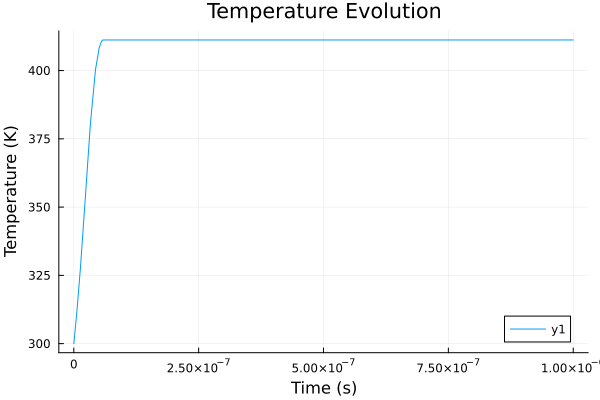

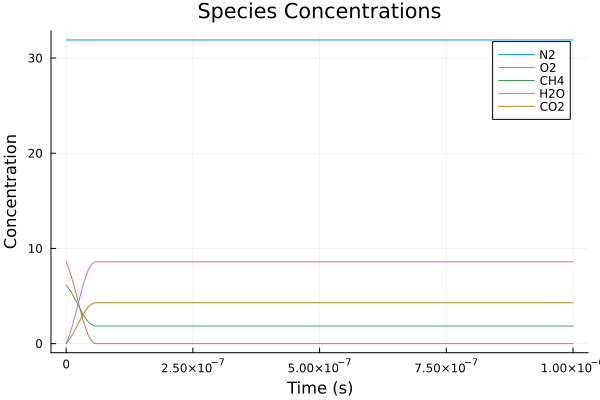

In [5]:
# Extract the solution arrays
t = sol.t
T = sol[1, :]
C = sol[2:end, :]'

# Create a plot for the temperature
plot1 = plot(t, T, xlabel="Time (s)", ylabel="Temperature (K)", title="Temperature Evolution")

display(plot1)

# Create a plot for the species concentrations
plot2 = plot(t, C, xlabel="Time (s)", ylabel="Concentration", title="Species Concentrations", label=["N2" "O2" "CH4" "H2O" "CO2"])

display(plot2)